In [17]:
import os
from collections import OrderedDict
from pathlib import Path
from typing import Callable, cast

import kagglehub
import numpy as np
import pandas as pd
import torch
import wandb
from google.colab import userdata
from huggingface_hub import login
from matplotlib import pyplot as plt
from PIL import Image
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tensorflow.image import resize as tf_resize
from termcolor import colored
from torch import Tensor, nn, optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, models, transforms
from torchvision.models import EfficientNet_B0_Weights
from tqdm import tqdm
from transformers import AutoModel, AutoProcessor

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


In [2]:
# Retrieve secret
hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
! rm -rf retinal-disease-classification
!git clone -b develop https://github.com/Tejashree-Khot/medsiglip-448-finetune.git
%cd /content/medsiglip-448-finetune/src

Cloning into 'medsiglip-448-finetune'...
fatal: could not read Username for 'https://github.com': No such device or address
[Errno 2] No such file or directory: '/content/medsiglip-448-finetune/src'
/content


In [5]:
path = kagglehub.dataset_download("mariaherrerot/idrid-dataset")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/idrid-dataset


In [6]:
! ls /kaggle/input/idrid-dataset

idrid_labels.csv  Imagenes


In [7]:
! ls /kaggle/input/idrid-dataset/Imagenes/Imagenes/IDRiD_001.jpg

/kaggle/input/idrid-dataset/Imagenes/Imagenes/IDRiD_001.jpg


In [8]:
model = AutoModel.from_pretrained("google/medsiglip-448")
processor = AutoProcessor.from_pretrained("google/medsiglip-448")
model.to(DEVICE)

config.json:   0%|          | 0.00/879 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.51G [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/360 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json:   0%|          | 0.00/809 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/455 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.40M [00:00<?, ?B/s]

SiglipModel(
  (text_model): SiglipTextTransformer(
    (embeddings): SiglipTextEmbeddings(
      (token_embedding): Embedding(32000, 1152)
      (position_embedding): Embedding(64, 1152)
    )
    (encoder): SiglipEncoder(
      (layers): ModuleList(
        (0-26): 27 x SiglipEncoderLayer(
          (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
          (self_attn): SiglipAttention(
            (k_proj): Linear(in_features=1152, out_features=1152, bias=True)
            (v_proj): Linear(in_features=1152, out_features=1152, bias=True)
            (q_proj): Linear(in_features=1152, out_features=1152, bias=True)
            (out_proj): Linear(in_features=1152, out_features=1152, bias=True)
          )
          (layer_norm2): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
          (mlp): SiglipMLP(
            (activation_fn): PytorchGELUTanh()
            (fc1): Linear(in_features=1152, out_features=4304, bias=True)
            (fc2): Linear(in_feature

In [9]:
imgs = [Image.open("/kaggle/input/idrid-dataset/Imagenes/Imagenes/IDRiD_001.jpg").convert("RGB"), Image.open("/kaggle/input/idrid-dataset/Imagenes/Imagenes/IDRiD_002.jpg").convert("RGB")]

In [43]:
# imgs[0]

In [19]:
# If you want to reproduce the results from MedSigLIP evals, we recommend a
# resizing operation with `tf.image.resize` to match the implementation with the
# Big Vision library (https://github.com/google-research/big_vision/blob/0127fb6b337ee2a27bf4e54dea79cff176527356/big_vision/pp/ops_image.py#L84).
# Otherwise, you can rely on the Transformers image processor's built-in
# resizing (done automatically by default and uses `PIL.Image.resize`) or use
# another resizing method.

def resize(image):
    return Image.fromarray(
        tf_resize(
            images=image, size=[448, 448], method='bilinear', antialias=False
        ).numpy().astype(np.uint8)
    )


resized_imgs = [resize(img) for img in imgs]

texts = [
    "retina is having Clinically_Significant_Macular_Edema",
    "retina is having No_DR",
    "retina is normal",
    "retina is having Mild_Moderate_NPDR",
    "retina is having Severe_PDR"
]


In [20]:
inputs = processor(text=texts, images=resized_imgs, padding="max_length", return_tensors="pt").to(DEVICE)

In [21]:
inputs["pixel_values"].shape

torch.Size([2, 3, 448, 448])

In [22]:
inputs["input_ids"].shape

torch.Size([5, 64])

In [23]:
with torch.no_grad():
    outputs = model(**inputs)

logits_per_image = outputs.logits_per_image
probs = torch.softmax(logits_per_image, dim=1)

for n_img, img in enumerate(imgs):
    print(f"{img.size}\n")
    # display(img)  # Note this is an IPython function that will only work in a Jupyter notebook environment
    for i, label in enumerate(texts):
        print(f"{probs[n_img][i]:.2%} that image is '{label}'")

# Get the image and text embeddings
print(f"image embeddings: {outputs.image_embeds}")
print(f"text embeddings: {outputs.text_embeds}")

(4288, 2848)

34.16% that image is 'retina is having Clinically_Significant_Macular_Edema'
12.91% that image is 'retina is having No_DR'
9.89% that image is 'retina is normal'
20.08% that image is 'retina is having Mild_Moderate_NPDR'
22.96% that image is 'retina is having Severe_PDR'
(4288, 2848)

32.95% that image is 'retina is having Clinically_Significant_Macular_Edema'
16.50% that image is 'retina is having No_DR'
9.36% that image is 'retina is normal'
17.10% that image is 'retina is having Mild_Moderate_NPDR'
24.10% that image is 'retina is having Severe_PDR'
image embeddings: tensor([[-0.0148, -0.0177,  0.0070,  ...,  0.0083,  0.0017,  0.0386],
        [-0.0074, -0.0309,  0.0046,  ...,  0.0245,  0.0099,  0.0330]],
       device='cuda:0')
text embeddings: tensor([[-0.0245,  0.0118, -0.0121,  ...,  0.0265, -0.0148,  0.0331],
        [ 0.0013, -0.0055, -0.0217,  ...,  0.0239, -0.0140,  0.0129],
        [-0.0094,  0.0070, -0.0438,  ...,  0.0234, -0.0136,  0.0341],
        [-0.0211, 

In [101]:
# outputs

In [24]:
outputs.image_embeds.shape


torch.Size([2, 1152])

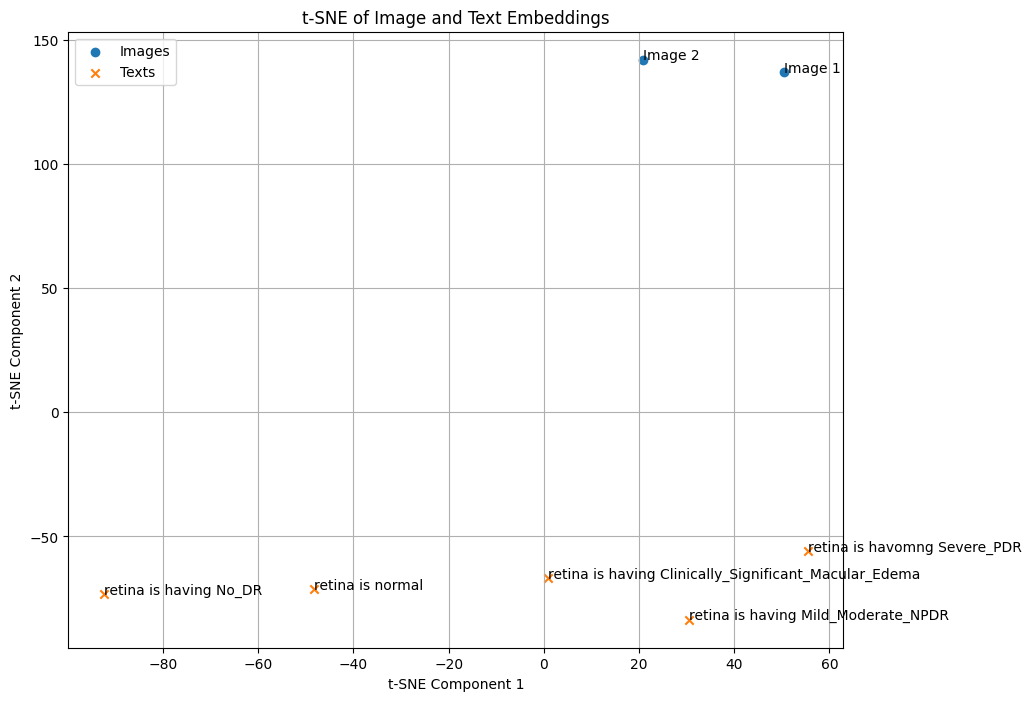

In [18]:
# Combine image and text embeddings
embeddings = torch.cat((outputs.image_embeds, outputs.text_embeds), dim=0).cpu().numpy()

# Create labels for the embeddings
labels = ["Image 1", "Image 2"] + texts

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=2)
embeddings_tsne = tsne.fit_transform(embeddings)

# Plot the t-SNE results
plt.figure(figsize=(10, 8))

# Separate image and text embeddings for plotting
image_embeddings_tsne = embeddings_tsne[:len(imgs)]
text_embeddings_tsne = embeddings_tsne[len(imgs):]

# Plot image embeddings
plt.scatter(image_embeddings_tsne[:, 0], image_embeddings_tsne[:, 1], label='Images', marker='o')

# Plot text embeddings
plt.scatter(text_embeddings_tsne[:, 0], text_embeddings_tsne[:, 1], label='Texts', marker='x')


# Annotate points with labels
for i, label in enumerate(labels):
    plt.annotate(label, (embeddings_tsne[i, 0], embeddings_tsne[i, 1]))

plt.title('t-SNE of Image and Text Embeddings')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.legend() # Add legend
plt.show()